In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b8= bd.iloc[124]

In [4]:
b8['datetime']

'2020-09-13,07:54:26.713971+00:00'

In [5]:
lat= literal_eval(b8['lat_stereo_g17'])
long= literal_eval(b8['lon_stereo_g17'])
alt= literal_eval(b8['alt_stereo_g17'])
energy = literal_eval(b8['energyJoules_stereo_g17'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

63 63 63 63


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

47


In [9]:
totalmass= 0
totalh= 0 
for i in range (47): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.00013922057377195588 6.49696010935794e-05 0.0006496960109357941


In [11]:
totalh

24422.7814132621

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

-0.0007491100000009965
-0.00047745999999904143
1.9410000007269446e-05
0.000521570000003635
2.1099999997886698e-05
0.00027990999998905863
0.0002462500000035561
-0.0007528299999961519
-0.0007710499999973308
-0.0007634400000000596
-0.0007627600000006396
-0.001498560000001703
0.0004837000000037506
2.8142135699999926
-0.0012646400000022595
-0.001255929999999239
-0.0012507799999923463
-0.0002688000000006241
0.0004350899999963076
0.0006899899999979198
0.00043510000000424043
0.00043418999999289554
0.00019667000000822554
0.000804610000002981
0.0010751800000008416
0.0008003799999869443
0.0010706700000042702
-0.0004275099999944132
-0.002023330000000101
-0.0025451700000047595
-0.0022794099999998707
-0.0025346900000045025
-0.0018103799999948933
-0.0004760700000048246
-0.00047189000000003034
0.8404123000000112
0.6198061999999993
-0.0007437400000043226
0.0004875700000042116
-5.134343999999999
0.0005287699999882989
0.001026160000009213
0.0007565499999913072
0.00026223999999785974
-0.000977229999989504

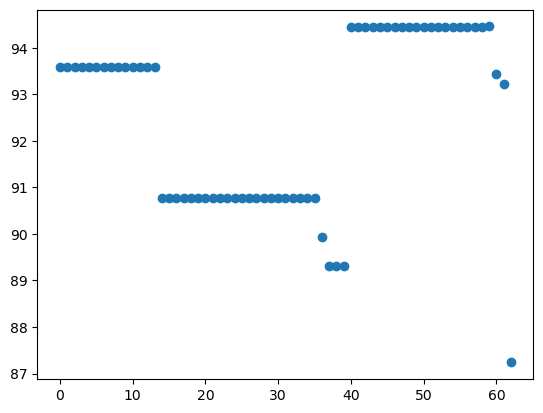

In [13]:
plt.scatter(range(len(alt)), alt)